In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
print(df.columns)

Index(['CustomerId', 'CredRate', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'Prod Number', 'HasCrCard', 'ActMem', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [ ]:
df.drop('CustomerId', axis=1, inplace=True)

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = ['CredRate', 'Age', 'Tenure', 'Balance', 'Prod Number', 'HasCrCard', 'ActMem', 'EstimatedSalary']

In [ ]:
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check for NaNs and impute after one-hot encoding, but before train-test split
if df_final.isnull().sum().sum() > 0:
    print("NaNs found in df_final. Imputing with median...")
    for col in df_final.columns:
        if df_final[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_final[col]):
                df_final[col] = df_final[col].fillna(df_final[col].median())
else:
    print("No NaNs found in df_final.")

NaNs found in df_final. Imputing with median...


In [ ]:
X = df_final.drop('Exited', axis=1)
y = df_final['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print("MODEL PERFORMANCE TESTING")
print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions))

MODEL PERFORMANCE TESTING
Accuracy Score: 0.7195

Confusion Matrix:
[[1159  448]
 [ 113  280]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



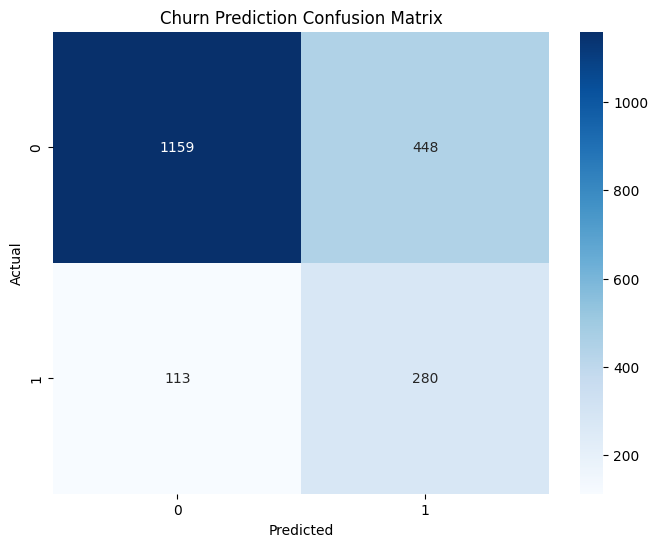

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Prediction Confusion Matrix')
plt.show()

In [ ]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)
print("\nTop Predictors for Churn:")
print(importance.head(5))


Top Predictors for Churn:
             Feature  Coefficient
1                Age     0.811665
8  Geography_Germany     0.769547
3            Balance     0.172411
9    Geography_Spain     0.110690
7    EstimatedSalary     0.016993


In [ ]:
import joblib
joblib.dump(model, 'churn_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_train.columns.tolist(), 'model_columns.joblib')

print("Success: Model, Scaler, and Columns saved to disk.")

Success: Model, Scaler, and Columns saved to disk.


In [ ]:
import pandas as pd
import numpy as np
import joblib

loaded_model = joblib.load('churn_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
model_columns = joblib.load('model_columns.joblib')

def predict_churn(customer_data):
    # Convert input data to DataFrame
    input_df = pd.DataFrame([customer_data])

    # Define categorical columns for one-hot encoding, consistent with training
    categorical_cols_for_pred = ['Geography', 'Gender']

    # Apply one-hot encoding
    # Ensure consistent handling of categories by explicitly defining them if possible, or using the 'columns' argument
    # For simplicity, we assume new categories will be handled by reindex fill_value=0
    input_df = pd.get_dummies(input_df, columns=categorical_cols_for_pred, drop_first=True)

    # Reindex to ensure all columns match training data and fill missing with 0
    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    # Define numerical columns for scaling, consistent with training
    # This list must match the 'numerical_cols' used in the StandardScaler fit_transform step
    num_cols_to_scale = ['CredRate', 'Age', 'Tenure', 'Balance', 'Prod Number', 'HasCrCard', 'ActMem', 'EstimatedSalary']
    input_df[num_cols_to_scale] = loaded_scaler.transform(input_df[num_cols_to_scale])

    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0][1]

    return "CHURN (Yes)" if prediction == 1 else "STAY (No)", probability

# Example usage with new customer data for the bank churn model
# These values should be raw, unscaled values that align with your original df columns
new_customer_example = {
    'CredRate': 600,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 35,
    'Tenure': 5,
    'Balance': 100000.0,
    'Prod Number': 1,
    'HasCrCard': 1,
    'ActMem': 1,
    'EstimatedSalary': 50000.0
}

res, p = predict_churn(new_customer_example)
print(f"Result for example customer: {res} (Probability of Churn: {p:.2%})")

Result for example customer: STAY (No) (Probability of Churn: 30.42%)
